# Robust Regression Engine

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV

from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df = pd.read_csv('../Dataset/HousePrice.csv')
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


# Dataset Understanding

In [3]:
print('Shape :', df.shape)
df.info()

Shape : (3800, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


# Missing Values

In [4]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

# Duplicate Values

In [5]:
df.duplicated().sum()

0

# Statistical Summary

In [6]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


# House Price Distribution

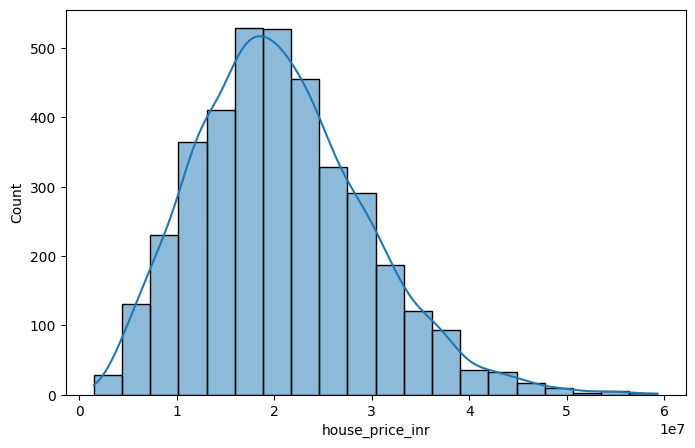

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['house_price_inr'], bins=20, kde=True)
plt.show()

# Correlation Heatmap

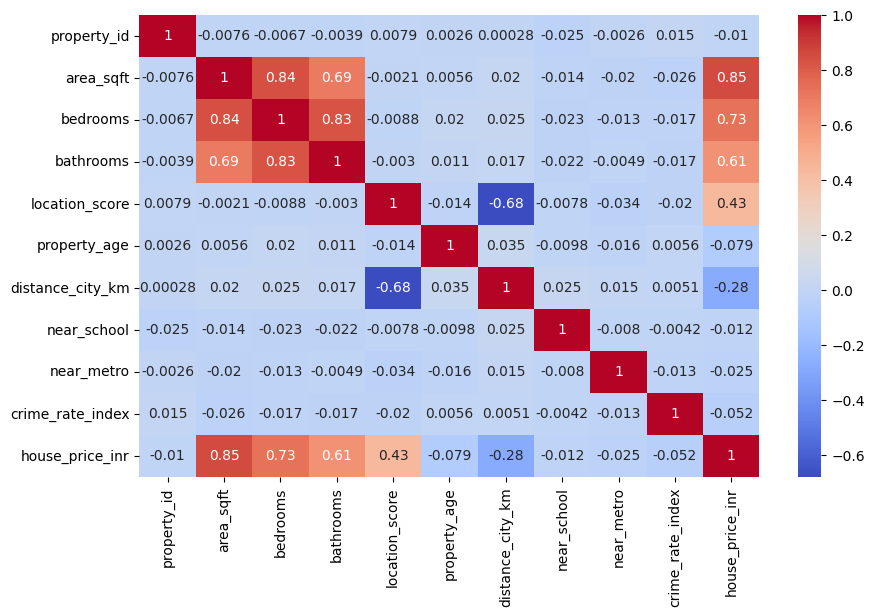

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# Outlier Detection

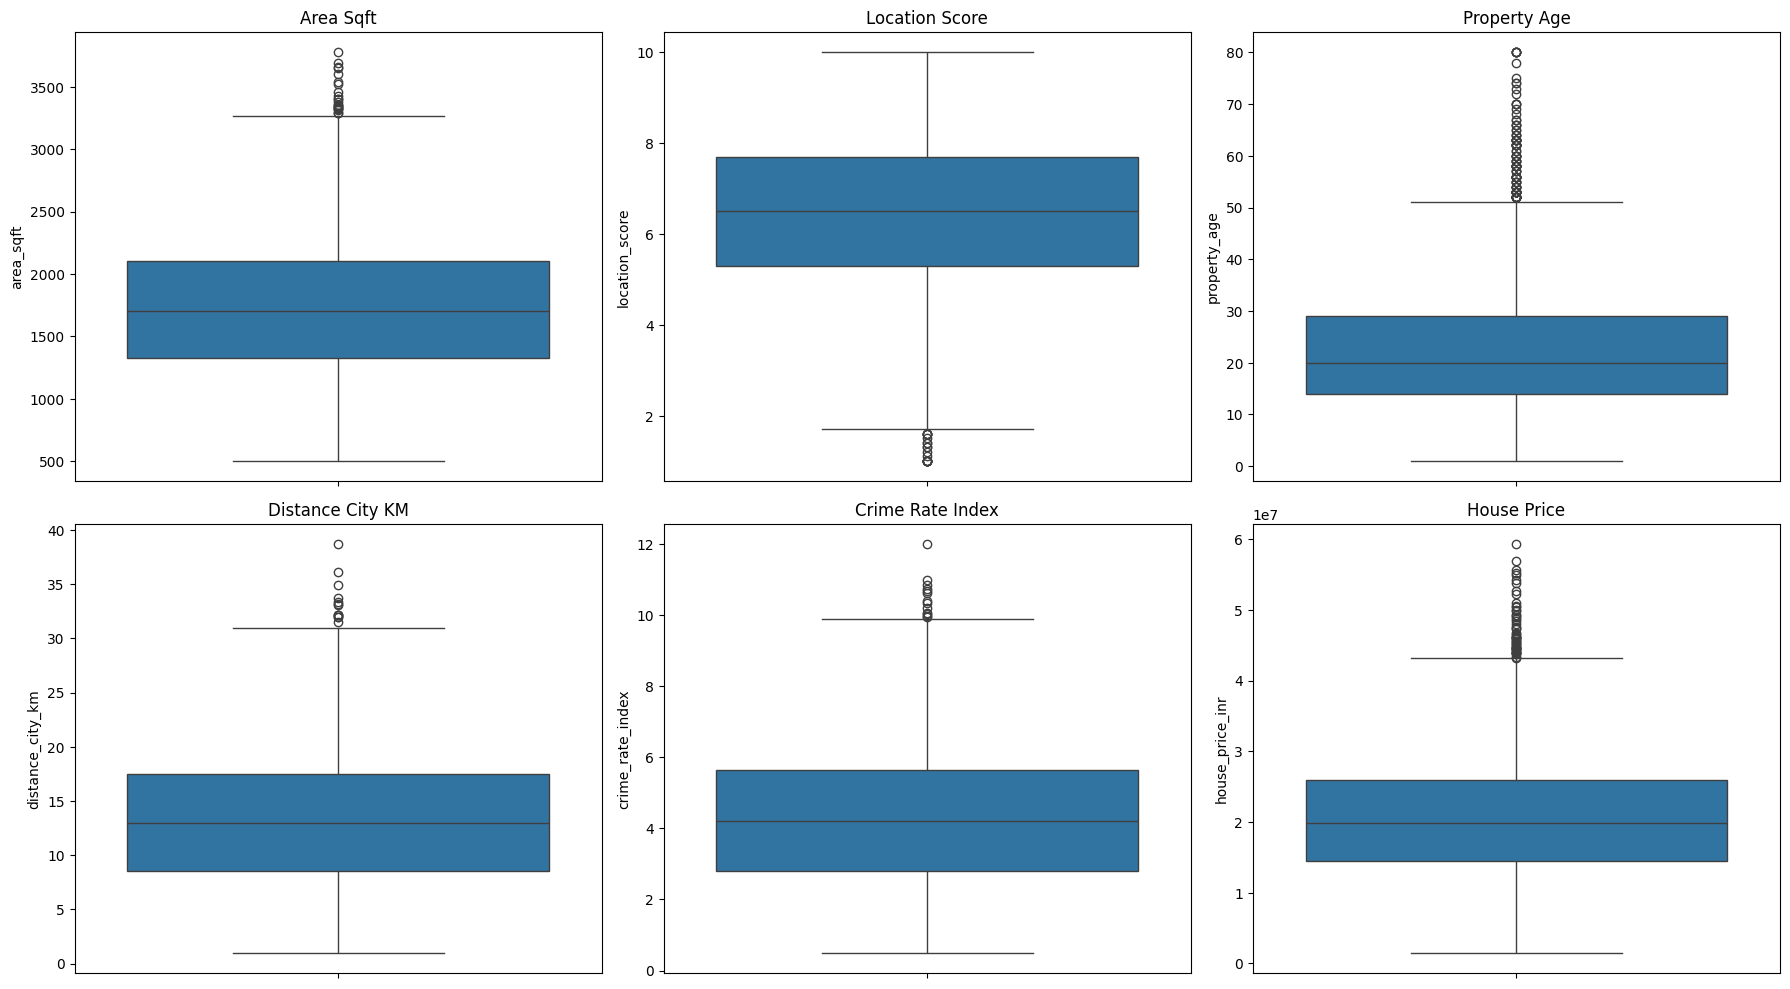

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

sns.boxplot(y=df['area_sqft'],ax=axes[0,0])
axes[0,0].set_title('Area Sqft')

sns.boxplot(y=df['location_score'],ax=axes[0,1])
axes[0,1].set_title('Location Score')

sns.boxplot(y=df['property_age'],ax=axes[0,2])
axes[0,2].set_title('Property Age')

sns.boxplot(y=df['distance_city_km'],ax=axes[1,0])
axes[1,0].set_title('Distance City KM')

sns.boxplot(y=df['crime_rate_index'],ax=axes[1,1])
axes[1,1].set_title('Crime Rate Index')

sns.boxplot(y=df['house_price_inr'],ax=axes[1,2])
axes[1,2].set_title('House Price')

plt.tight_layout()
plt.show()

# Feature Preparation

In [10]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

df['sale_year'] = df['sale_date'].dt.year
df['sale_month'] = df['sale_date'].dt.month

df.drop(['property_id','sale_date'], axis=1, inplace=True)

df.head()

,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,sale_year,sale_month
0,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,2014,1
1,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,2019,12
2,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,2016,10
3,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,2013,3
4,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,2013,7


# Features and Target Variable

In [11]:
X = df.drop('house_price_inr', axis=1)
y = df['house_price_inr']

# Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print(X_train.shape)
print(X_test.shape)

(3040, 11)
(760, 11)


# Feature Scaling

In [13]:
scale_columns = ['area_sqft','location_score','property_age','distance_city_km','crime_rate_index']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[scale_columns] = scaler.fit_transform(X_train[scale_columns])
X_test_scaled[scale_columns] = scaler.transform(X_test[scale_columns])

# Ridge Regression

In [14]:
ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)
ridge_train_pred = ridge.predict(X_train_scaled)

ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


# Lasso Regression

In [15]:
lasso = Lasso(alpha=1)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)
lasso_train_pred = lasso.predict(X_train_scaled)

lasso

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


# Hyperparameter Tuning

In [16]:
alphas = [0.01,0.1,1,10,100]

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train_scaled, y_train)

print('Best Ridge Alpha :', ridge_cv.alpha_)
print('Best Lasso Alpha :', lasso_cv.alpha_)


Best Ridge Alpha : 1.0
Best Lasso Alpha : 100.0


# Training and Validation Error Comparison

In [17]:
comparison = pd.DataFrame({
    'Model':['Ridge','Lasso'],
    'Training RMSE':[
        np.sqrt(mean_squared_error(y_train, ridge_train_pred)),
        np.sqrt(mean_squared_error(y_train, lasso_train_pred))
    ],
    'Validation RMSE':[
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ]
})

comparison

,Model,Training RMSE,Validation RMSE
0,Ridge,2.482399e+06,2.539953e+06
1,Lasso,2.482395e+06,2.539709e+06


# Feature Coefficients

In [18]:
coef_df = pd.DataFrame({
    'Feature':X_train.columns,
    'Ridge':ridge.coef_,
    'Lasso':lasso.coef_
})

coef_df

,Feature,Ridge,Lasso
0,area_sqft,6.948533e+06,6.956027e+06
1,bedrooms,2.177174e+05,2.130325e+05
2,bathrooms,2.398799e+05,2.400032e+05
3,location_score,3.678705e+06,3.680811e+06
4,property_age,-6.499448e+05,-6.501217e+05
5,distance_city_km,-2.852148e+04,-2.714710e+04
6,near_school,3.155719e+04,3.144923e+04
7,near_metro,1.051378e+05,1.054177e+05
8,crime_rate_index,-1.406943e+05,-1.406249e+05
9,sale_year,7.481817e+04,7.484182e+04


# K Fold Cross Validation

In [19]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_score = cross_val_score(ridge,X_train_scaled,y_train,cv=kfold,scoring='r2')

print(kfold_score.mean())

0.916305828899031


# Stratified K Fold Cross Validation

In [20]:
bins = pd.qcut(y_train, q=5, labels=False)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, test_idx in skf.split(X_train_scaled, bins):
    X_tr = X_train_scaled.iloc[train_idx]
    X_te = X_train_scaled.iloc[test_idx]
    y_tr = y_train.iloc[train_idx]
    y_te = y_train.iloc[test_idx]

    model = Ridge(alpha=1)
    model.fit(X_tr, y_tr)

    scores.append(model.score(X_te, y_te))

print(np.mean(scores))

0.9167386357981375


# Leave One Out Cross Validation

In [21]:
loo = LeaveOneOut()

sample_X = X_train_scaled.head(100)
sample_y = y_train.head(100)

loo_score = cross_val_score(Ridge(alpha=1),sample_X,sample_y,cv=loo,scoring='r2')

print(np.nanmean(loo_score))

nan


# Time Series Split

In [22]:
tscv = TimeSeriesSplit(n_splits=5)

time_scores = cross_val_score(
    Ridge(alpha=1),
    X_train_scaled,
    y_train,
    cv=tscv,
    scoring='r2'
)

print(time_scores.mean())

0.9160462874160068


# Compare Cross Validation Methods

In [23]:
cv_results = pd.DataFrame({
    'Method':['K Fold','Stratified K Fold','LOOCV','Time Series Split'],
    'Mean R2':[
        kfold_score.mean(),
        np.mean(scores),
        np.nanmean(loo_score),
        time_scores.mean()
    ]
})

cv_results

,Method,Mean R2
0,K Fold,0.916306
1,Stratified K Fold,0.916739
2,LOOCV,NaN
3,Time Series Split,0.916046


# Decision Tree Regression

In [24]:
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

# Random Forest Regression

In [25]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# SVR Linear Kernel

In [26]:
svr_linear = SVR(kernel='linear', C=10)

svr_linear.fit(X_train_scaled, y_train)

svr_linear_pred = svr_linear.predict(X_test_scaled)

svr_linear

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


# SVR RBF Kernel

In [27]:
svr_rbf = SVR(kernel='rbf', C=100, gamma='scale')

svr_rbf.fit(X_train_scaled, y_train)

svr_rbf_pred = svr_rbf.predict(X_test_scaled)

svr_rbf

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


# Model Evaluation Function

In [28]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return [mae, mse, rmse, r2]

# Model Comparison

In [29]:
results = pd.DataFrame({
    'Model':['Ridge','Lasso','Decision Tree','Random Forest','SVR Linear','SVR RBF'],
    'MAE':[
        evaluate_model(y_test,ridge_pred)[0],
        evaluate_model(y_test,lasso_pred)[0],
        evaluate_model(y_test,dt_pred)[0],
        evaluate_model(y_test,rf_pred)[0],
        evaluate_model(y_test,svr_linear_pred)[0],
        evaluate_model(y_test,svr_rbf_pred)[0]
    ],
    'MSE':[
        evaluate_model(y_test,ridge_pred)[1],
        evaluate_model(y_test,lasso_pred)[1],
        evaluate_model(y_test,dt_pred)[1],
        evaluate_model(y_test,rf_pred)[1],
        evaluate_model(y_test,svr_linear_pred)[1],
        evaluate_model(y_test,svr_rbf_pred)[1]
    ],
    'RMSE':[
        evaluate_model(y_test,ridge_pred)[2],
        evaluate_model(y_test,lasso_pred)[2],
        evaluate_model(y_test,dt_pred)[2],
        evaluate_model(y_test,rf_pred)[2],
        evaluate_model(y_test,svr_linear_pred)[2],
        evaluate_model(y_test,svr_rbf_pred)[2]
    ],
    'R2 Score':[
        evaluate_model(y_test,ridge_pred)[3],
        evaluate_model(y_test,lasso_pred)[3],
        evaluate_model(y_test,dt_pred)[3],
        evaluate_model(y_test,rf_pred)[3],
        evaluate_model(y_test,svr_linear_pred)[3],
        evaluate_model(y_test,svr_rbf_pred)[3]
    ]
})

results.style.format({
    'MAE': '{:,.2f}',
    'MSE': '{:,.2f}',
    'RMSE': '{:,.2f}',
    'R2 Score': '{:.2f}'
})

,Model,MAE,MSE,RMSE,R2 Score
0,Ridge,"1,945,383.24","6,451,363,139,140.66","2,539,953.37",0.92
1,Lasso,"1,945,519.93","6,450,122,696,440.50","2,539,709.18",0.92
2,Decision Tree,"2,325,303.89","9,385,836,459,040.17","3,063,631.25",0.88
3,Random Forest,"1,757,755.01","5,785,958,403,336.22","2,405,401.92",0.93
4,SVR Linear,"6,944,886.11","79,681,933,648,158.42","8,926,473.75",0.01
5,SVR RBF,"6,994,138.97","80,774,278,497,423.86","8,987,451.17",-0.00


# Conclusion

In this project, multiple machine learning models were used to predict house prices. The models were evaluated using MAE, MSE, RMSE, and R² Score.

Among all the models, **Random Forest Regression** performed the best with an **R² Score of 0.93** and the lowest prediction error. This indicates that Random Forest was able to capture the relationship between the features and house prices more effectively than the other models.

Therefore, **Random Forest Regression is selected as the best model for house price prediction in this dataset.**